In [32]:
import matplotlib.pyplot as plt
import pandas as pd

In [46]:
caminho_dados = r"C:\Projetos\LearningDataAnalysis\dados\mediaEnemPorMunicipio.csv"

In [47]:
caminho_municipios = r"C:\Projetos\LearningDataAnalysis\dados\atlasMunicipios.csv"

In [77]:
dadosEnem = pd.read_csv(caminho_dados, sep=",", encoding='ISO-8859-1', index_col=0)

In [78]:
municipios = pd.read_csv(caminho_municipios, sep=",", encoding='utf-8')

In [87]:
municipios = municipios[municipios['ANO'] == 2010] #ESCOLHENDO O ANO DE ANALISE

In [88]:
enem_municipios = pd.merge(dadosEnem, municipios, how='left', left_on=['CO_MUNICIPIO_ESC'], right_on=['Codmun7'])

In [86]:
mediaEnemIDHM = enem_municipios.filter(['CO_MUNICIPIO_ESC','NO_MUNICIPIO_ESC', 'SG_UF_ESC',
                                  'CO_UF_ESC', 'NU_NOTA_MT', 'NU_NOTA_LC',
                                  'NU_NOTA_CH', 'NU_NOTA_CN', 'NU_NOTA_REDACAO',
                                  'IDHM', 'IDHM_E', 'IDHM_L', 'IDHM_R'])
mediaEnemIDHM 

,CO_MUNICIPIO_ESC,NO_MUNICIPIO_ESC,SG_UF_ESC,CO_UF_ESC,NU_NOTA_MT,NU_NOTA_LC,NU_NOTA_CH,NU_NOTA_CN,NU_NOTA_REDACAO,IDHM,IDHM_E,IDHM_L,IDHM_R
0,1100015.0,Alta Floresta D'Oeste,RO,11.0,502.991429,495.929730,543.020270,480.664286,453.783784,0.641,0.526,0.763,0.657
1,1100023.0,Ariquemes,RO,11.0,512.975890,513.304727,549.247267,481.314239,461.418021,0.702,0.600,0.806,0.716
2,1100031.0,Cabixi,RO,11.0,484.925000,466.007407,506.685185,442.604167,391.111111,0.650,0.559,0.757,0.650
3,1100049.0,Cacoal,RO,11.0,524.946720,513.924809,549.739357,484.990720,482.419602,0.718,0.620,0.821,0.727
4,1100056.0,Cerejeiras,RO,11.0,493.949296,498.394737,551.494737,466.433803,440.789474,0.692,0.602,0.799,0.688
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5553,5222005.0,VianÃ³polis,GO,52.0,503.091765,493.386517,522.414607,474.571765,446.516854,0.712,0.622,0.818,0.710
5554,5222054.0,VicentinÃ³polis,GO,52.0,479.803226,463.625641,498.125641,439.651613,362.051282,0.684,0.562,0.804,0.707
5555,5222203.0,Vila Boa,GO,52.0,504.900000,450.394444,513.100000,440.164286,346.666667,0.647,0.534,0.818,0.619
5556,5222302.0,Vila PropÃ­cio,GO,52.0,471.051667,463.396825,498.101587,451.296667,369.206349,0.634,0.505,0.802,0.629


In [93]:
mean_Redacao=mediaEnemIDHM.NU_NOTA_REDACAO.mean()
mean_Redacao

np.float64(460.15101082295433)

In [94]:
mean_IDHM=mediaEnemIDHM.IDHM.mean()
mean_IDHM

np.float64(0.6591845849090582)

Quadrante 1: Alto IDHM, Baixa Nota: 19.29%
Quadrante 2: Baixo IDHM, Baixa Nota: 32.84%
Quadrante 3: Alto IDHM, Alta Nota: 33.14%
Quadrante 4: Baixo IDHM, Alta Nota: 14.57%


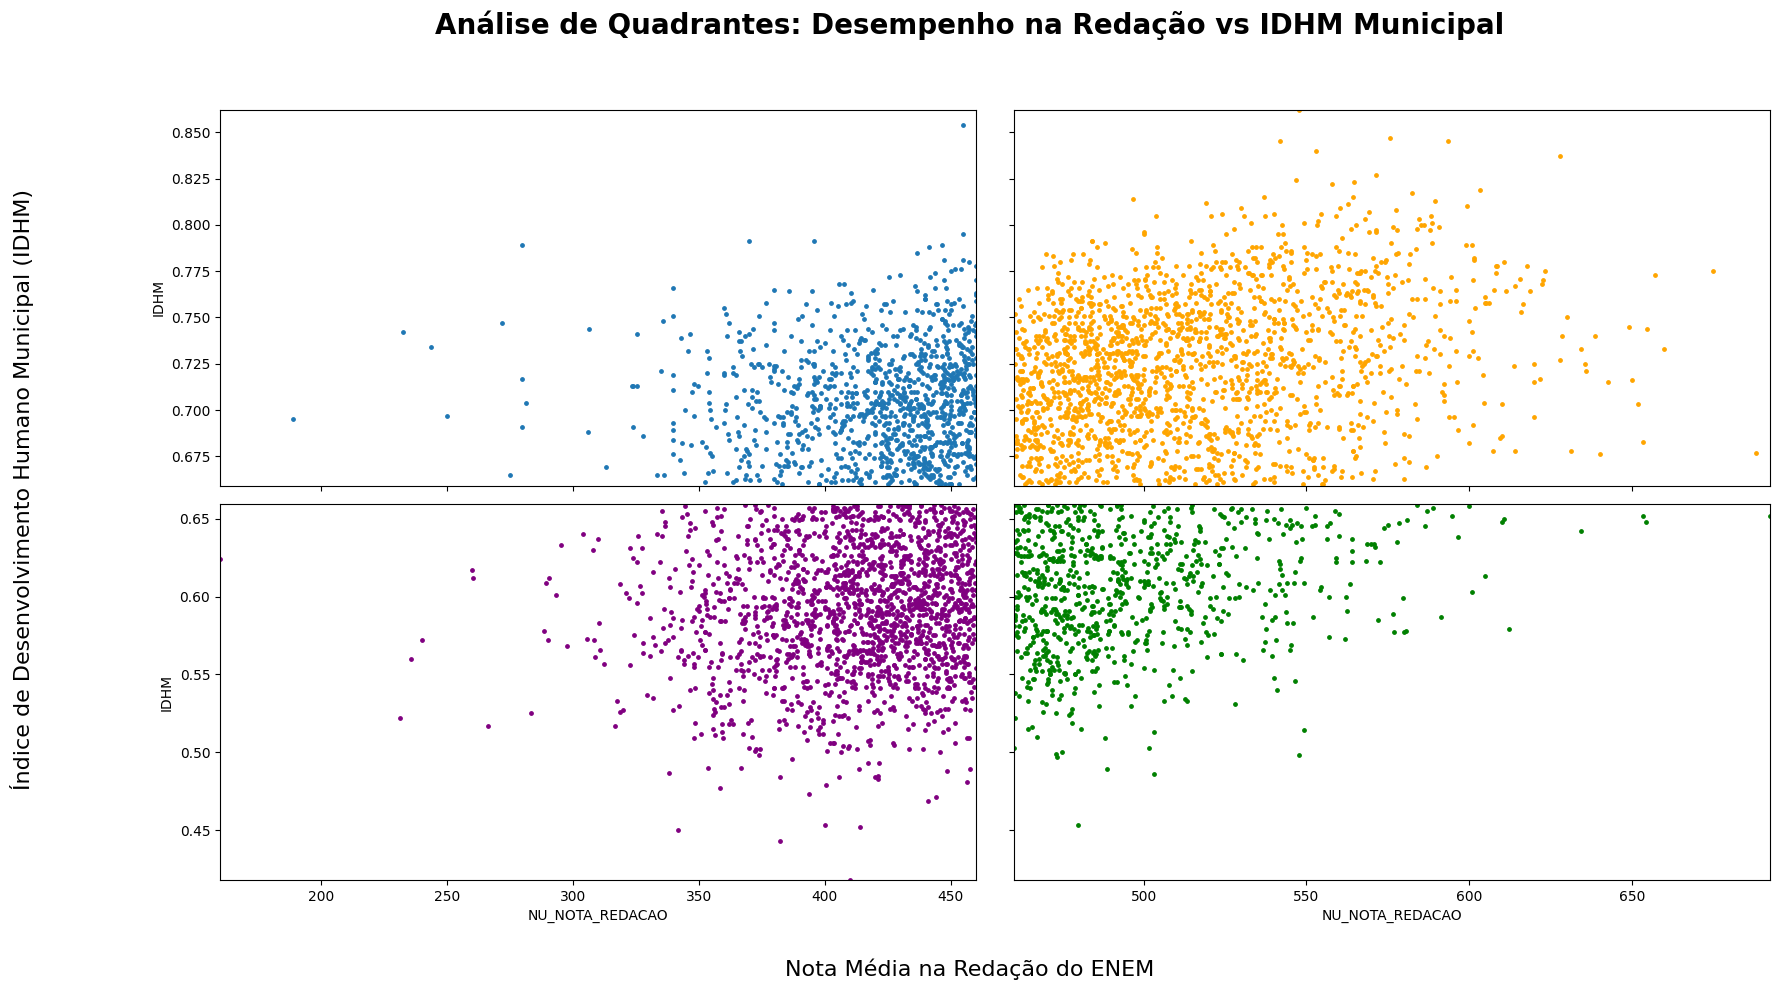

In [216]:
idhmMunicipio = mediaEnemIDHM.IDHM
notaMunicipio = mediaEnemIDHM.NU_NOTA_REDACAO
quadrante1 = (idhmMunicipio > mean_IDHM) & (notaMunicipio < mean_Redacao)
quadrante2 = (idhmMunicipio < mean_IDHM) & (notaMunicipio < mean_Redacao)
quadrante3 = (idhmMunicipio > mean_IDHM) & (notaMunicipio > mean_Redacao)
quadrante4 = (idhmMunicipio < mean_IDHM) & (notaMunicipio > mean_Redacao)

minRedacao = mediaEnemIDHM.NU_NOTA_REDACAO.min()
maxRedacao = mediaEnemIDHM.NU_NOTA_REDACAO.max()
minIDHM = mediaEnemIDHM.IDHM.min()
maxIDHM = mediaEnemIDHM.IDHM.max()

fig, ax = plt.subplots(2, 2, figsize=(20, 10), sharex='col', sharey='row')
fig.suptitle('Análise de Quadrantes: Desempenho na Redação vs IDHM Municipal', fontsize=20, fontweight='bold')
plt.subplots_adjust(wspace=0.05, hspace=0.05)

# Q1: Superior Esquerdo
mediaEnemIDHM1 = mediaEnemIDHM[quadrante1]
porcentagem_q1 = 100 * len(mediaEnemIDHM1) / len(idhmMunicipio)
print(f'Quadrante 1: Alto IDHM, Baixa Nota: {porcentagem_q1:.2f}%')
mediaEnemIDHM1.plot.scatter('NU_NOTA_REDACAO', 'IDHM', s=6, ax=ax[0, 0], xlim=(minRedacao, mean_Redacao), ylim=(mean_IDHM, maxIDHM))

# Q2: Inferior Esquerdo
mediaEnemIDHM2 = mediaEnemIDHM[quadrante2]
porcentagem_q2 = 100 * len(mediaEnemIDHM2) / len(idhmMunicipio)
print(f'Quadrante 2: Baixo IDHM, Baixa Nota: {porcentagem_q2:.2f}%')
mediaEnemIDHM2.plot.scatter('NU_NOTA_REDACAO', 'IDHM', color='purple', s=6, ax=ax[1, 0], xlim=(minRedacao, mean_Redacao), ylim=(minIDHM, mean_IDHM))

# Q3: Superior Direito
mediaEnemIDHM3 = mediaEnemIDHM[quadrante3]
porcentagem_q3 = 100 * len(mediaEnemIDHM3) / len(idhmMunicipio)
print(f'Quadrante 3: Alto IDHM, Alta Nota: {porcentagem_q3:.2f}%')
mediaEnemIDHM3.plot.scatter('NU_NOTA_REDACAO', 'IDHM', color='orange', s=6, ax=ax[0, 1], xlim=(mean_Redacao, maxRedacao), ylim=(mean_IDHM, maxIDHM))

# Q4: Inferior Direito 
mediaEnemIDHM4 = mediaEnemIDHM[quadrante4]
porcentagem_q4 = 100 * len(mediaEnemIDHM4) / len(idhmMunicipio)
print(f'Quadrante 4: Baixo IDHM, Alta Nota: {porcentagem_q4:.2f}%')
mediaEnemIDHM4.plot.scatter('NU_NOTA_REDACAO', 'IDHM', color='green', s=6, ax=ax[1, 1], xlim=(mean_Redacao, maxRedacao), ylim=(minIDHM, mean_IDHM))

# Adicionando Labels Globais para os eixos (para não repetir nos 4 gráficos)
fig.supxlabel('Nota Média na Redação do ENEM', fontsize=16)
fig.supylabel('Índice de Desenvolvimento Humano Municipal (IDHM)', fontsize=16)

plt.show()

Agora vamos fazer uma análise da Nota de Matemática por IDHM

In [217]:
mean_mat=mediaEnemIDHM.NU_NOTA_MT.mean()
mean_mat

minMat = mediaEnemIDHM.NU_NOTA_MT.min()
maxMat = mediaEnemIDHM.NU_NOTA_MT.max()
minIDHM = mediaEnemIDHM.IDHM.min()
maxIDHM = mediaEnemIDHM.IDHM.max()

In [218]:
#Declarações
idhmMunicipio = mediaEnemIDHM.IDHM
notaMunicipio = mediaEnemIDHM.NU_NOTA_MT

In [219]:
#Definição dos Quadrantes
quadrante1 = (idhmMunicipio > mean_IDHM) & (notaMunicipio < mean_mat)
quadrante2 = (idhmMunicipio < mean_IDHM) & (notaMunicipio < mean_mat)
quadrante3 = (idhmMunicipio > mean_IDHM) & (notaMunicipio > mean_mat)
quadrante4 = (idhmMunicipio < mean_IDHM) & (notaMunicipio > mean_mat)

In [ ]:
#declaração dos gráficos
fig, ax = plt.subplots(2, 2, figsize=(20, 10), sharex='col', sharey='row')
fig.suptitle('Análise de Quadrantes: Desempenho na Redação vs IDHM Municipal', fontsize=20, fontweight='bold')
plt.subplots_adjust(wspace=0, hspace=0)

#Definindo o Primeiro Quadrante
mediaEnemIDHM1 = mediaEnemIDHM[quadrante1]

porcentagem_q1 = 100 * len(mediaEnemIDHM1) / len(idhmMunicipio)
print(f'Quadrante 1: Alto IDHM, Baixa Nota: {porcentagem_q1:.2f}%')

mediaEnemIDHM1.plot.scatter('NU_NOTA_MT', 'IDHM', color='#1b9e77', s=6, ax=ax[0, 0], xlim=(minMat, mean_mat), ylim=(mean_IDHM, maxIDHM))



#Definindo o Segundo Quadrante
mediaEnemIDHM2 = mediaEnemIDHM[quadrante2]

porcentagem_q2 = 100 * len(mediaEnemIDHM2) / len(idhmMunicipio)
print(f'Quadrante 2: Baixo IDHM, Baixa Nota: {porcentagem_q2:.2f}%')

mediaEnemIDHM2.plot.scatter('NU_NOTA_MT', 'IDHM', color='purple', s=6, ax=ax[1, 0], xlim=(minMat, mean_mat), ylim=(minIDHM, mean_IDHM))



#Definindo o Terceiro Quadrante
mediaEnemIDHM3 = mediaEnemIDHM[quadrante3]

porcentagem_q3 = 100 * len(mediaEnemIDHM3) / len(idhmMunicipio)
print(f'Quadrante 3: Alto IDHM, Alta Nota: {porcentagem_q3:.2f}%')

mediaEnemIDHM3.plot.scatter('NU_NOTA_MT', 'IDHM', color='pink', s=6, ax=ax[0, 1], xlim=(mean_mat, maxMat), ylim=(mean_IDHM, maxIDHM))



#Definindo o Quarto Quadrante
mediaEnemIDHM4 = mediaEnemIDHM[quadrante4]

porcentagem_q4 = 100 * len(mediaEnemIDHM4) / len(idhmMunicipio)
print(f'Quadrante 4: Baixo IDHM, Alta Nota: {porcentagem_q4:.2f}%')

mediaEnemIDHM4.plot.scatter('NU_NOTA_MT', 'IDHM', color='#e74c3c', s=6, ax=ax[1, 1], xlim=(mean_mat, maxMat), ylim=(minIDHM, mean_IDHM))



#legenda indicando cada eixo do gráfico
fig.supxlabel('Nota Média em Matemática do ENEM', fontsize=16)
fig.supylabel('Índice de Desenvolvimento Humano Municipal (IDHM)', fontsize=16)

for eixo in ax.flat:
    eixo.set_xlabel('')
    eixo.set_ylabel('')
    
plt.show()